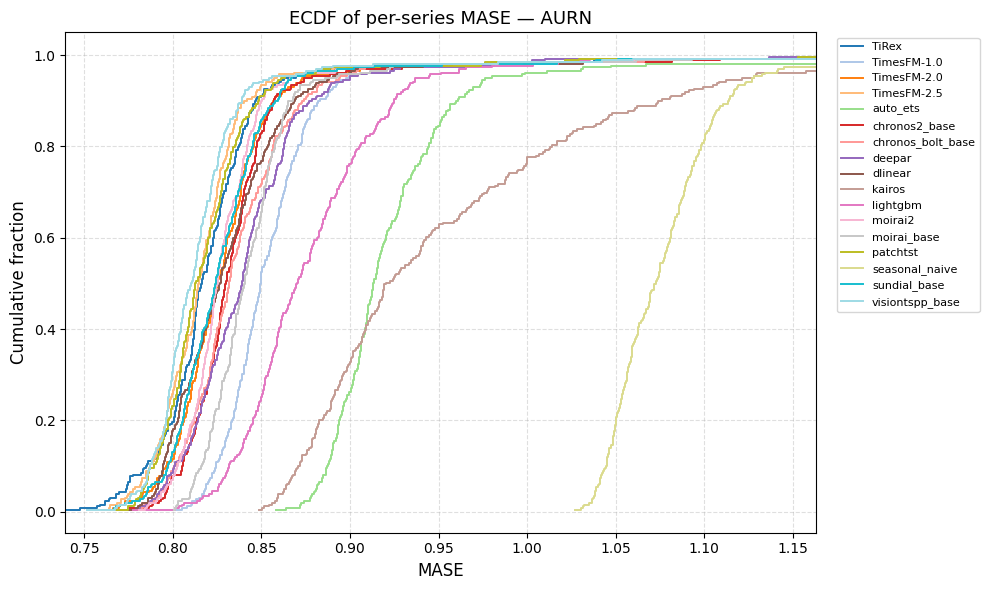

/tmp/ipykernel_230592/79240633.py:95: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=sorted_names, patch_artist=True, medianprops={"color": "black", "linewidth": 1.5})


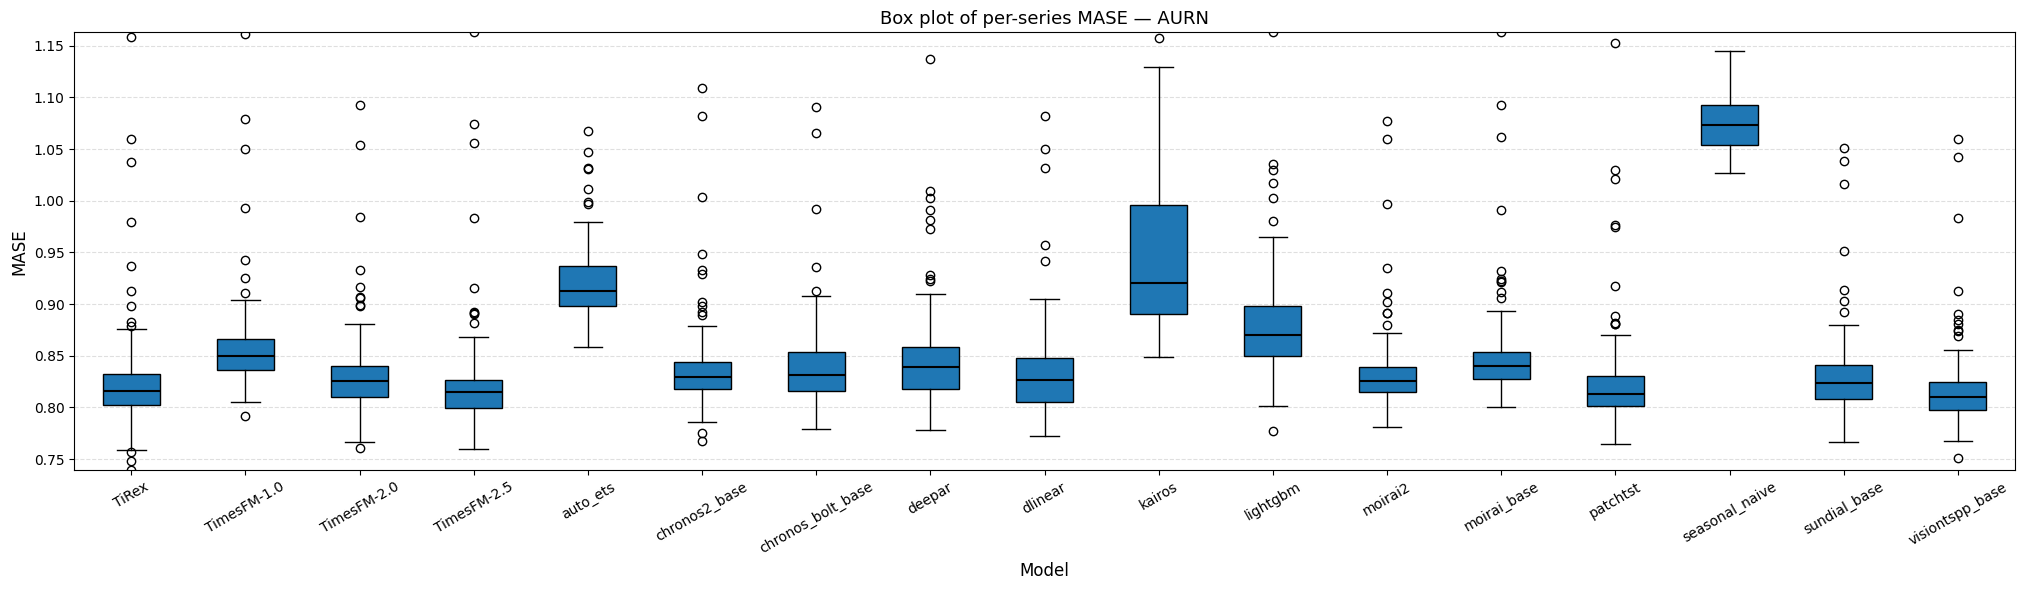

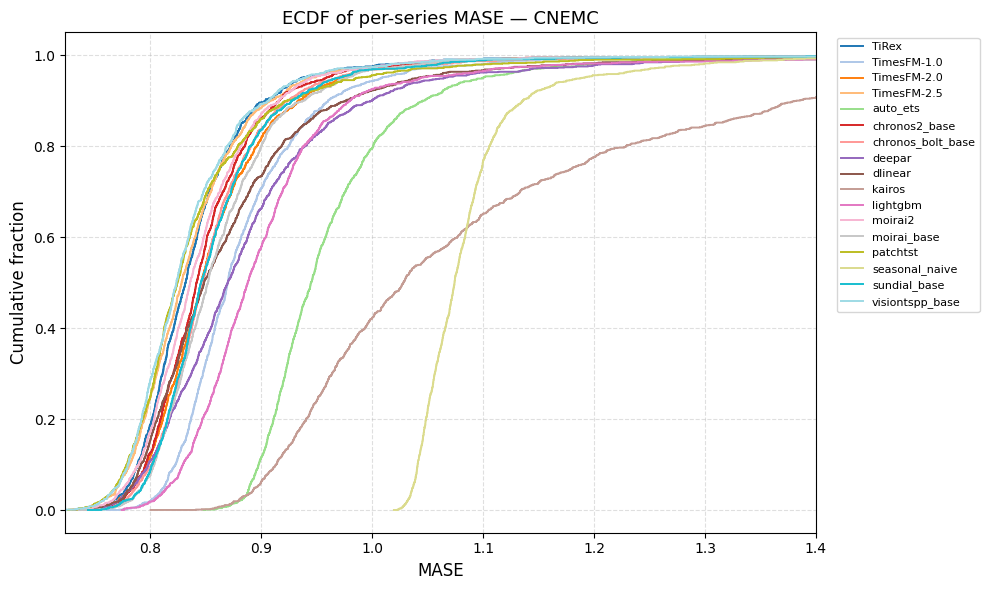

/tmp/ipykernel_230592/79240633.py:95: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=sorted_names, patch_artist=True, medianprops={"color": "black", "linewidth": 1.5})


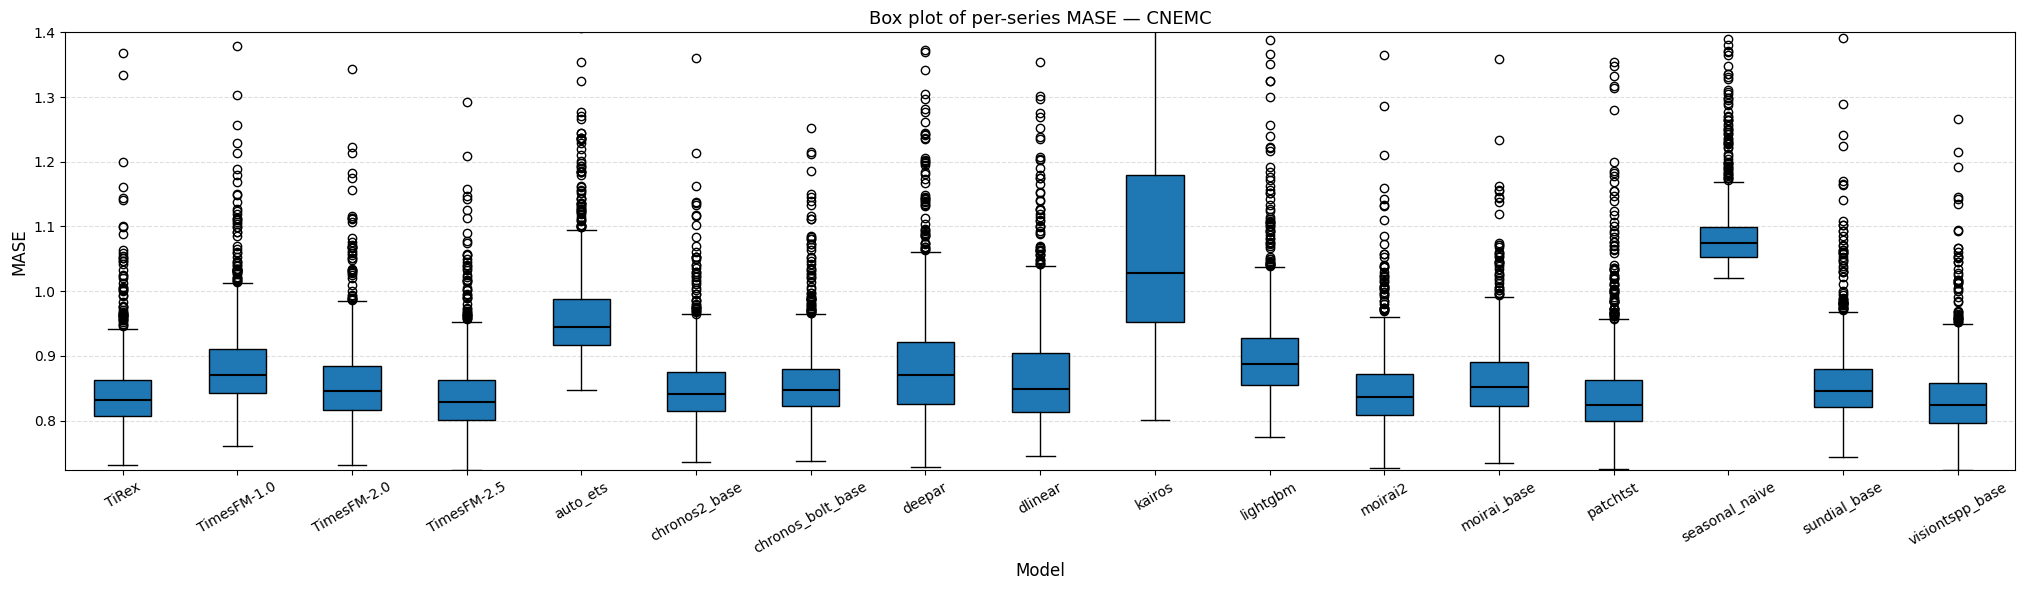

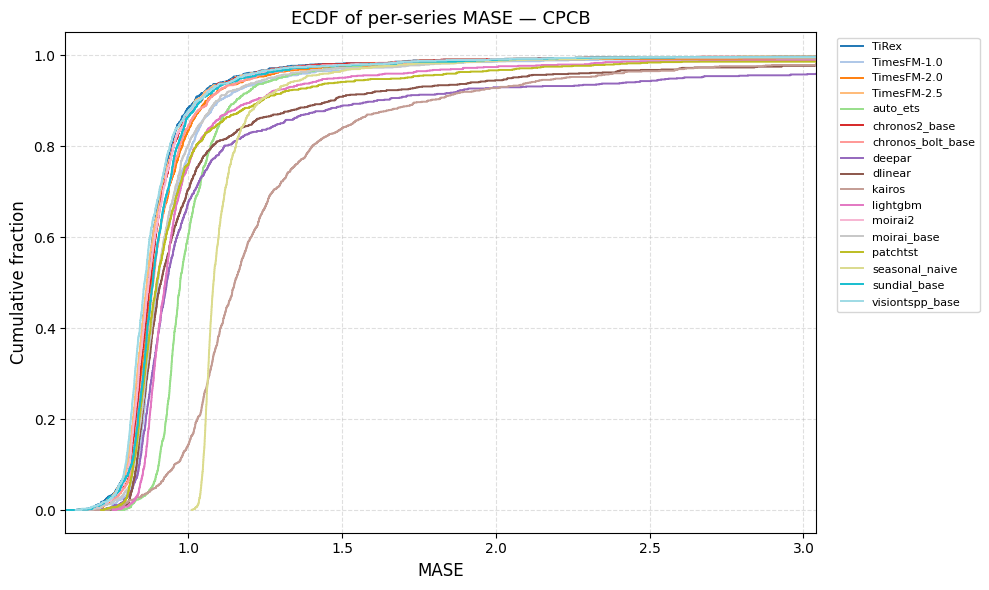

/tmp/ipykernel_230592/79240633.py:95: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=sorted_names, patch_artist=True, medianprops={"color": "black", "linewidth": 1.5})


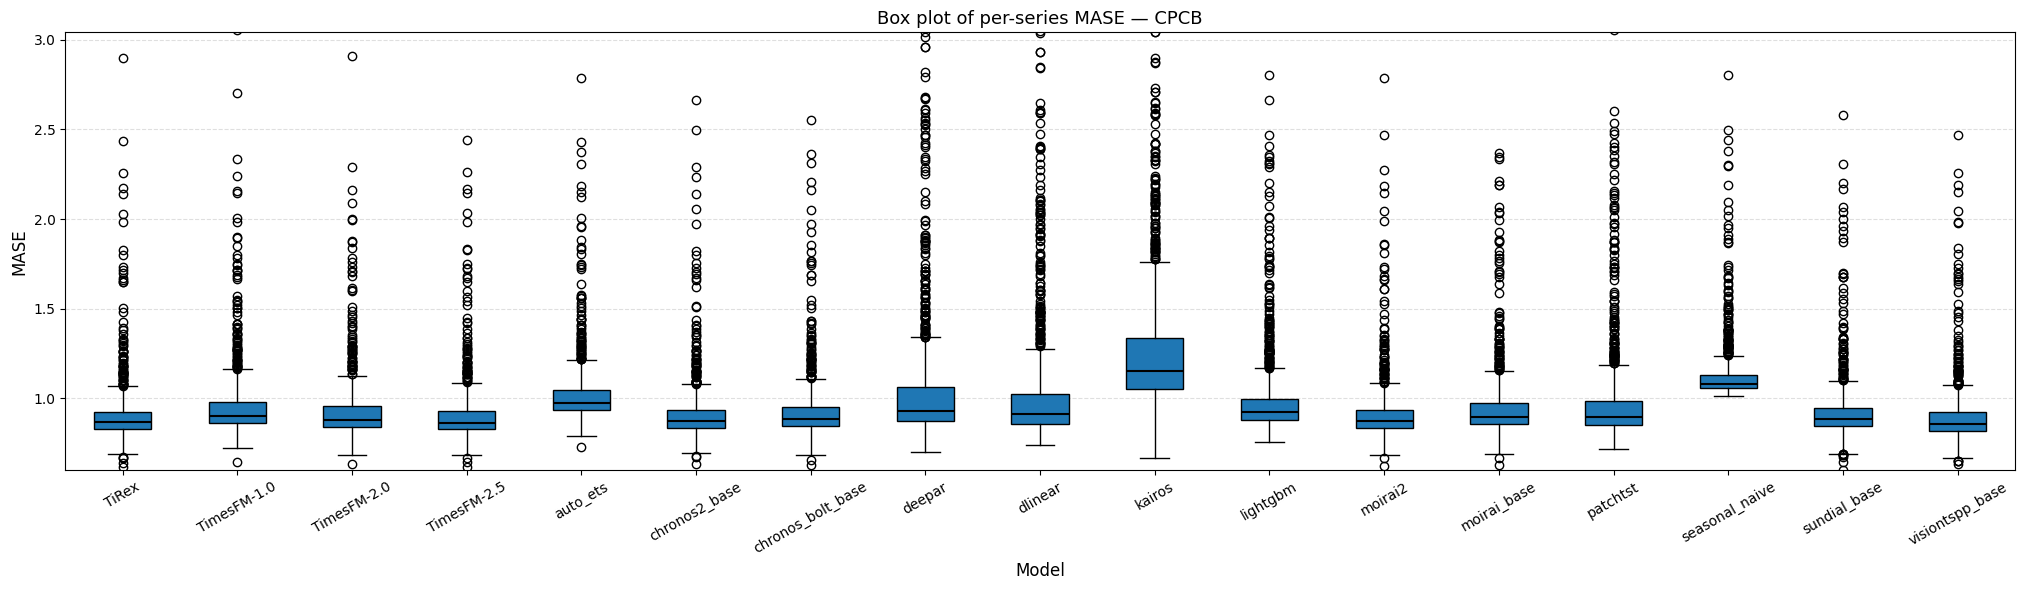

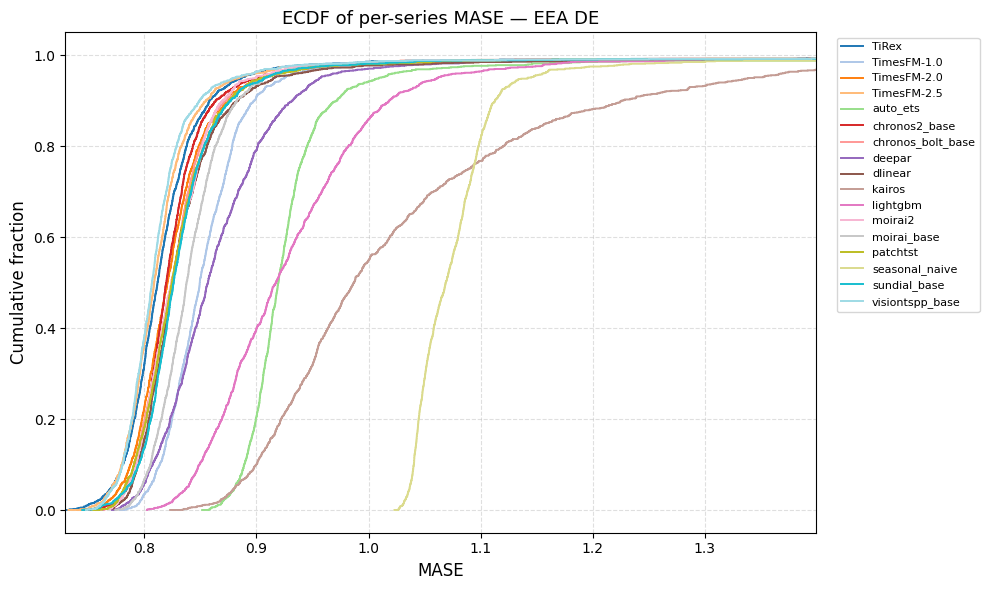

/tmp/ipykernel_230592/79240633.py:95: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=sorted_names, patch_artist=True, medianprops={"color": "black", "linewidth": 1.5})


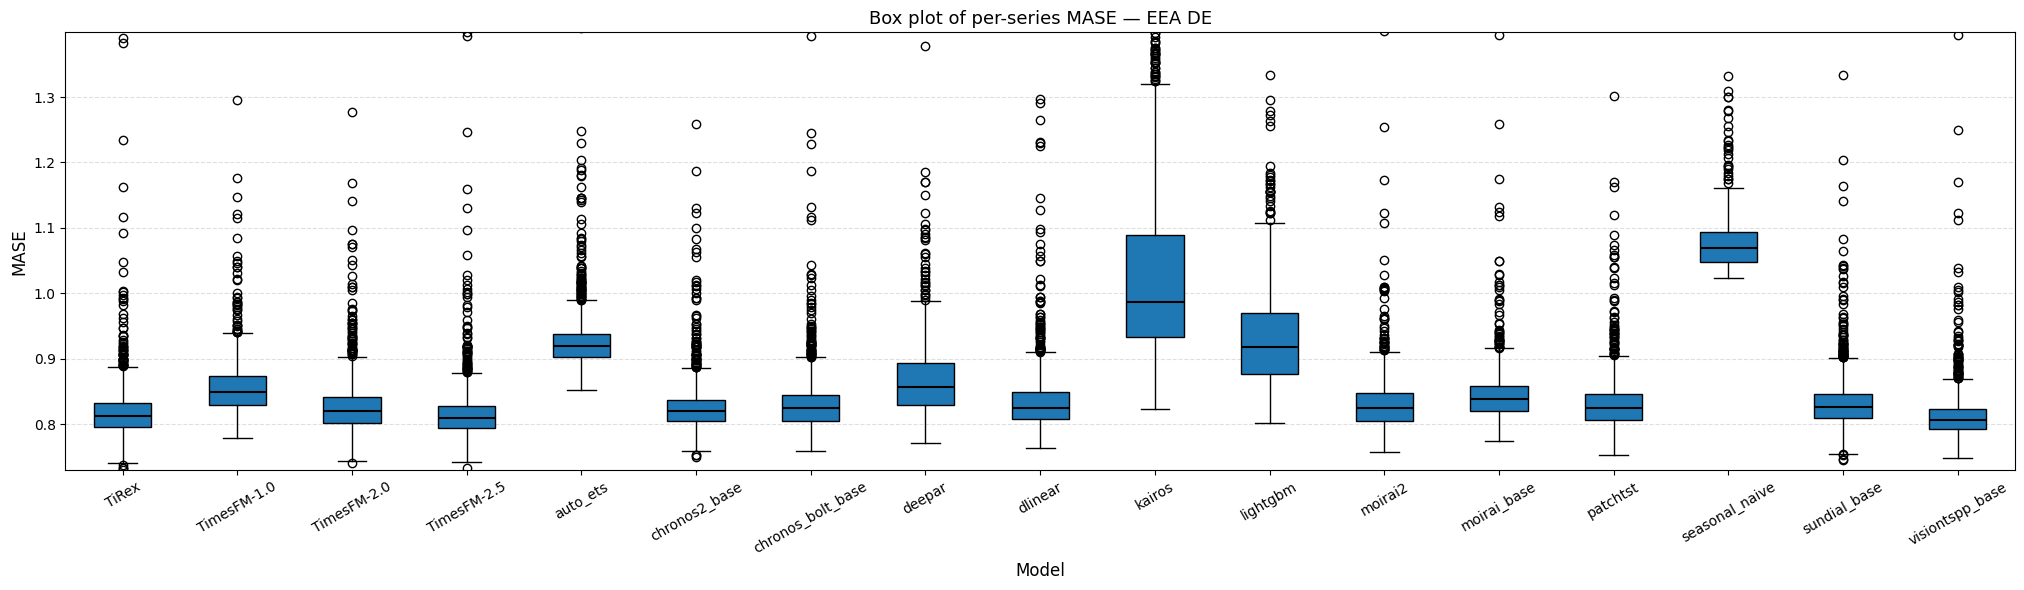

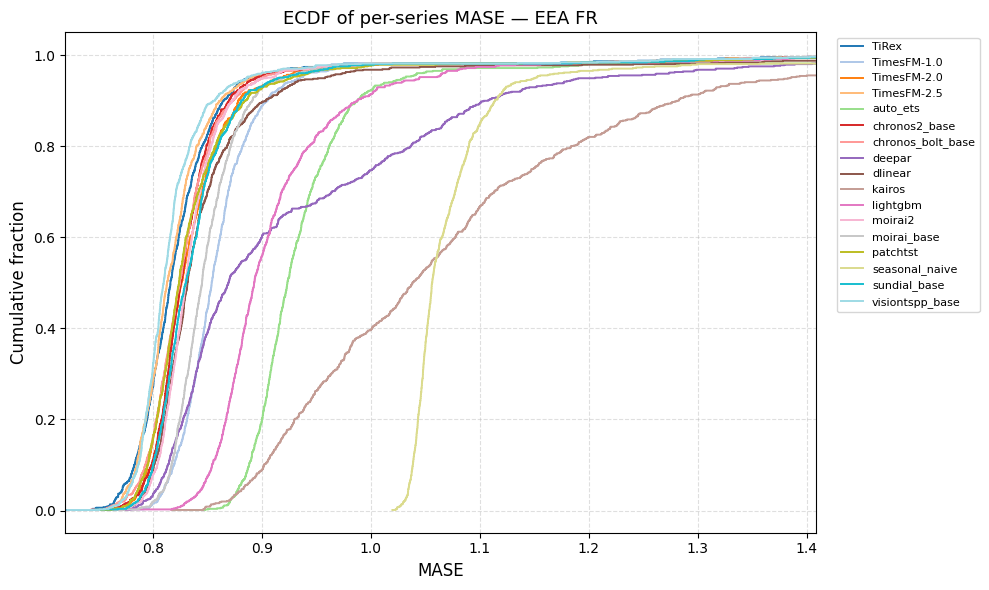

/tmp/ipykernel_230592/79240633.py:95: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=sorted_names, patch_artist=True, medianprops={"color": "black", "linewidth": 1.5})


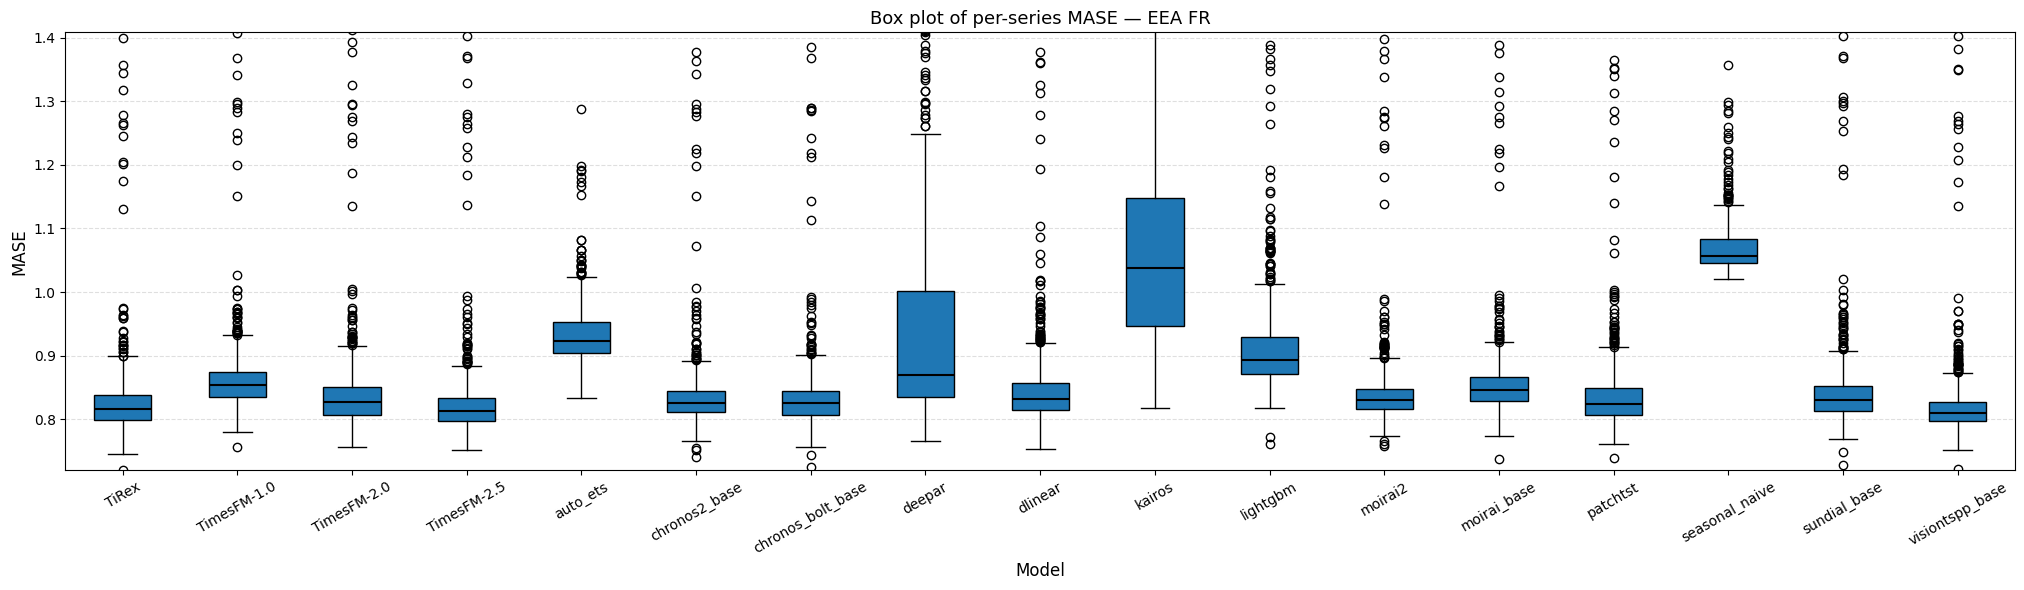

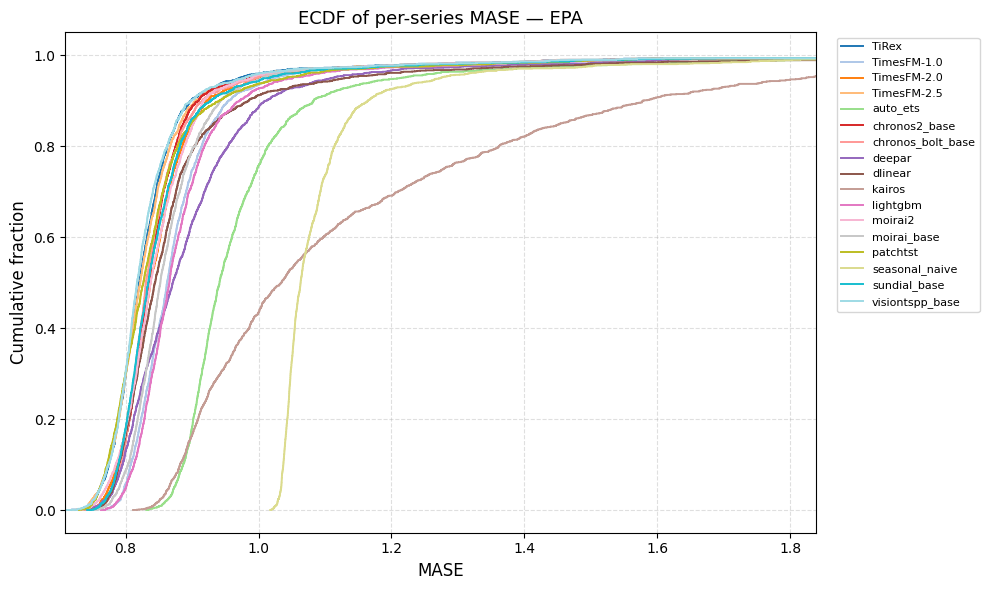

/tmp/ipykernel_230592/79240633.py:95: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=sorted_names, patch_artist=True, medianprops={"color": "black", "linewidth": 1.5})


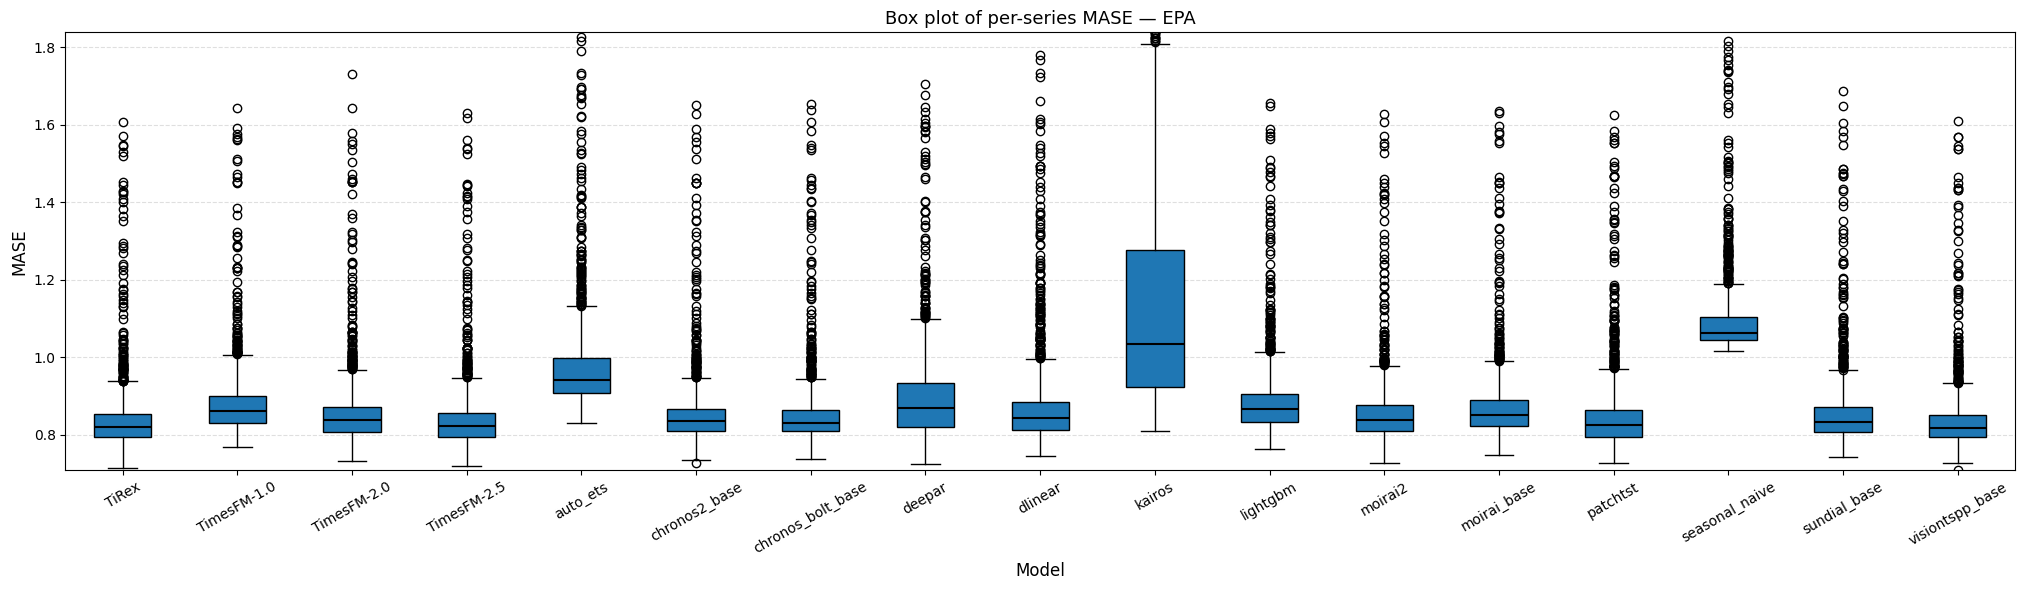

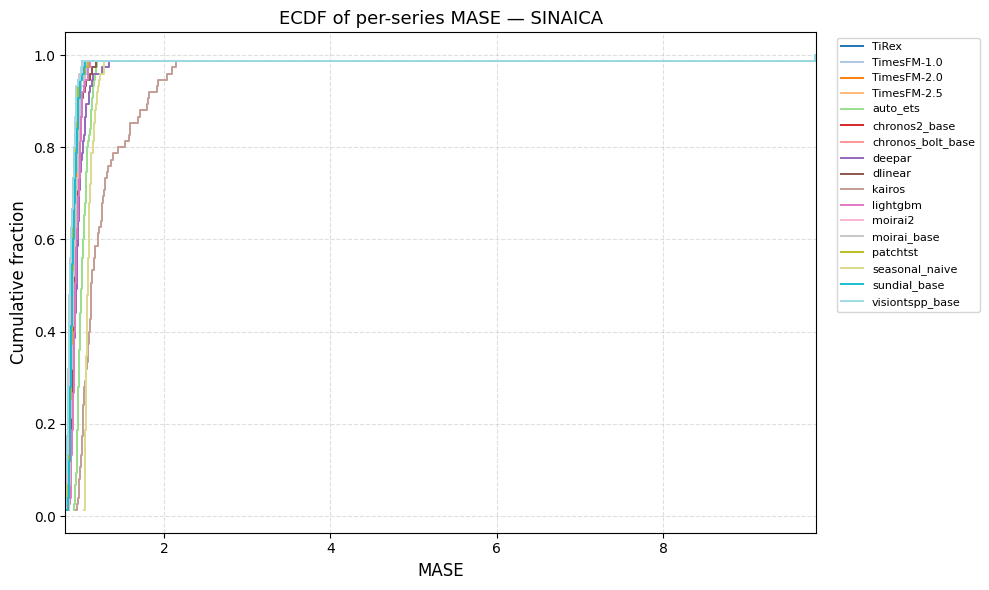

/tmp/ipykernel_230592/79240633.py:95: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=sorted_names, patch_artist=True, medianprops={"color": "black", "linewidth": 1.5})


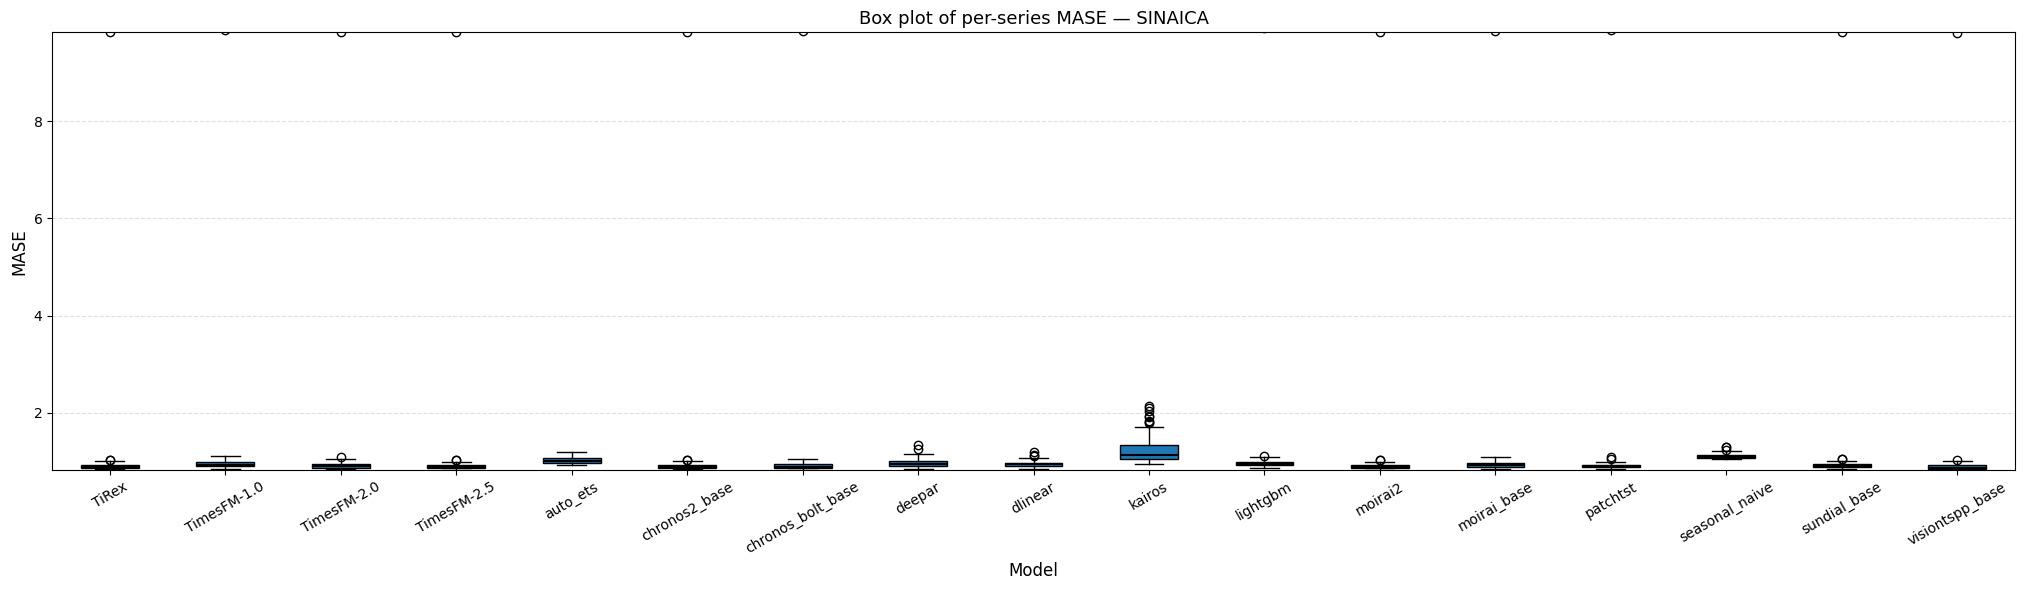

In [7]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

sys.path.insert(0, str(Path(".").resolve()))
sys.path.insert(0, str(Path("scripts").resolve()))

from compute_local_leaderboard import get_per_pollutant_results, _iter_model_series
from leaderboard_utils import extract_pollutant, display_dataset
from leaderboard_helpers import normalize_by_seasonal_naive, SEASONAL_NAIVE_MODEL

RESULTS_ROOT = Path("output/results")
PERCENTILE   = 99
THRESHOLD    = 50

# ── Collect raw per-site MASE for ECDFs & box plots ───────────────────────────
site_metric_values: dict[str, dict[tuple[str, str, str], list[float]]] = {"MASE": {}, "CRPS": {}}
for model_name, dataset_id, horizon, item_ids, npz_metrics in _iter_model_series(RESULTS_ROOT):
    n_series = len(item_ids)
    for metric_name in ["MASE", "CRPS"]:
        arr = npz_metrics.get(metric_name)
        if arr is None or arr.shape[0] != n_series:
            continue
        reduce_axes = tuple(range(1, arr.ndim))
        per_series = np.nanmean(arr[:n_series], axis=reduce_axes) if reduce_axes else arr[:n_series]
        for i, iid in enumerate(item_ids):
            val = per_series[i]
            if not np.isnan(val):
                site_metric_values[metric_name].setdefault((dataset_id, horizon, iid), []).append(float(val))

excluded_sites: dict[tuple[str, str], set[str]] = {}
for key in set(site_metric_values["MASE"]) | set(site_metric_values["CRPS"]):
    dataset_id, horizon, iid = key
    mase_vals = site_metric_values["MASE"].get(key, [])
    crps_vals = site_metric_values["CRPS"].get(key, [])
    if (mase_vals and np.mean(mase_vals) > THRESHOLD) or (crps_vals and np.mean(crps_vals) > THRESHOLD):
        excluded_sites.setdefault((dataset_id, horizon), set()).add(iid)

# ── Discover dataset_ids from raw results ─────────────────────────────────────
dataset_ids = sorted({
    f"{d.name}/{f.name}"
    for model_dir in RESULTS_ROOT.iterdir() if model_dir.is_dir()
    for d in model_dir.iterdir() if d.is_dir()
    for f in d.iterdir() if f.is_dir()
})

# ── Per-dataset: ECDF + Box plot ─────────────────────────────────────────────
for dataset_id in dataset_ids:
    ds_label = display_dataset(dataset_id)

    model_mase: dict[str, list[float]] = {}
    for model_name, _, horizon, item_ids, npz_metrics in _iter_model_series(RESULTS_ROOT, [dataset_id]):
        arr = npz_metrics.get("MASE")
        if arr is None:
            continue
        n_series = len(item_ids)
        reduce_axes = tuple(range(1, arr.ndim))
        per_series = np.nanmean(arr[:n_series], axis=reduce_axes) if reduce_axes else arr[:n_series]
        exclude_ids = excluded_sites.get((dataset_id, horizon), set())
        for i, iid in enumerate(item_ids):
            if iid in exclude_ids:
                per_series[i] = np.nan
        model_mase.setdefault(model_name, []).extend(per_series.tolist())

    if not model_mase:
        continue

    all_vals = [v for vals in model_mase.values() for v in vals if not np.isnan(v)]
    x_min = float(np.percentile(all_vals, 0))
    x_max = float(np.percentile(all_vals, PERCENTILE))
    sorted_names = sorted(model_mase.keys())
    colors = plt.cm.tab20(np.linspace(0, 1, len(sorted_names)))

    # ── ECDF ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 6))
    for idx, model_name in enumerate(sorted_names):
        vals = np.sort([v for v in model_mase[model_name] if not np.isnan(v)])
        ecdf = np.arange(1, len(vals) + 1) / len(vals)
        ax.step(vals, ecdf, label=model_name, where="post", linewidth=1.4, color=colors[idx])
    ax.set_xlim(left=x_min, right=x_max)
    ax.set_xlabel("MASE", fontsize=12)
    ax.set_ylabel("Cumulative fraction", fontsize=12)
    ax.set_title(f"ECDF of per-series MASE — {ds_label}", fontsize=13)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, framealpha=0.8)
    ax.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

    # ── Box plot ──────────────────────────────────────────────────────────────
    data = [[v for v in model_mase[m] if not np.isnan(v)] for m in sorted_names]
    fig, ax = plt.subplots(figsize=(max(8, len(sorted_names) * 1.2), 6))
    ax.boxplot(data, labels=sorted_names, patch_artist=True, medianprops={"color": "black", "linewidth": 1.5})
    ax.set_xlim(0.5, len(sorted_names) + 0.5)
    ax.set_ylim(bottom=x_min, top=x_max)
    ax.set_xlabel("Model", fontsize=12)
    ax.set_ylabel("MASE", fontsize=12)
    ax.set_title(f"Box plot of per-series MASE — {ds_label}", fontsize=13)
    ax.tick_params(axis="x", rotation=30)
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


  Dataset/horizon configs seen: 7 total
    TiRex: 7 configs
    TimesFM-1.0: 7 configs
    TimesFM-2.0: 7 configs
    TimesFM-2.5: 7 configs
    auto_ets: 7 configs
    chronos2_base: 7 configs
    chronos_bolt_base: 7 configs
    deepar: 7 configs
    dlinear: 7 configs
    kairos: 7 configs
    lightgbm: 7 configs
    moirai2: 7 configs
    moirai_base: 7 configs
    patchtst: 7 configs
    seasonal_naive: 7 configs
    sundial_base: 7 configs
    visiontspp_base: 7 configs

  Threshold (50) exclusions — mean MASE>threshold OR mean CRPS>threshold (applied to ALL models):
    CPCB/H/short: 1 site(s) excluded (CO: 1)
    EEA_DE/H/short: 22 site(s) excluded (NO2: 2, SO2: 20)
    EPA/H/short: 55 site(s) excluded (CO: 2, SO2: 53)


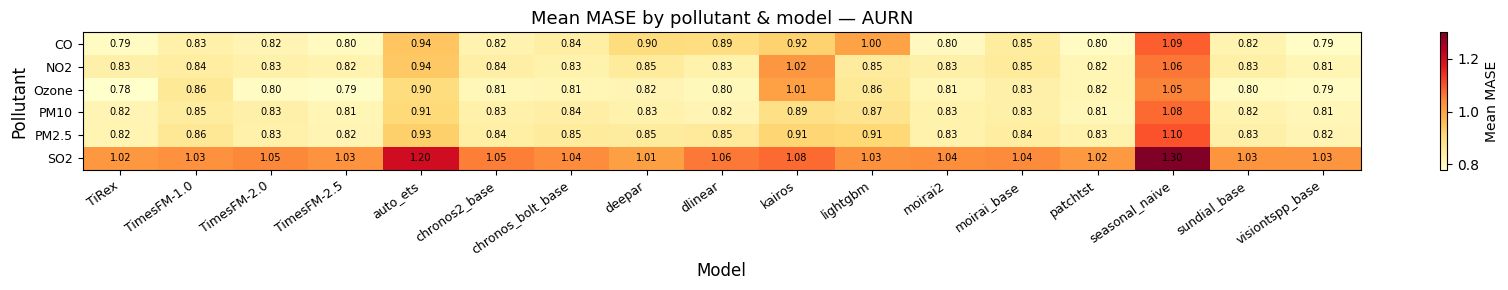

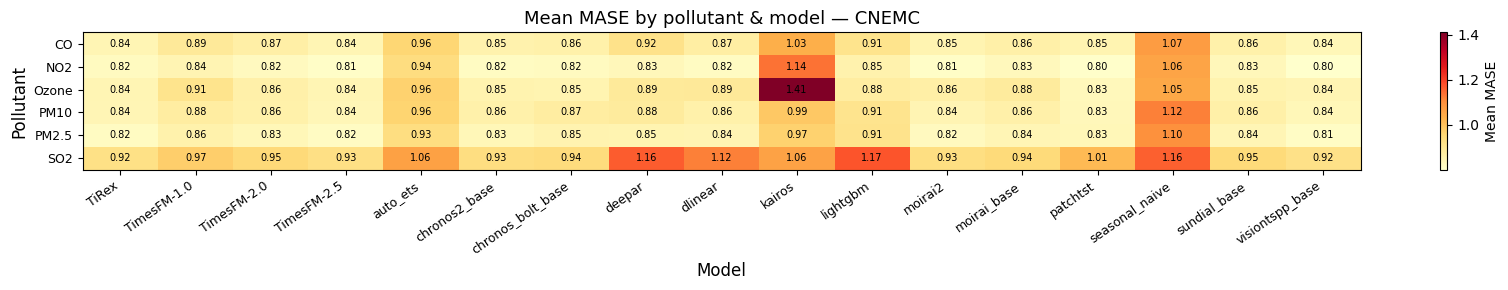

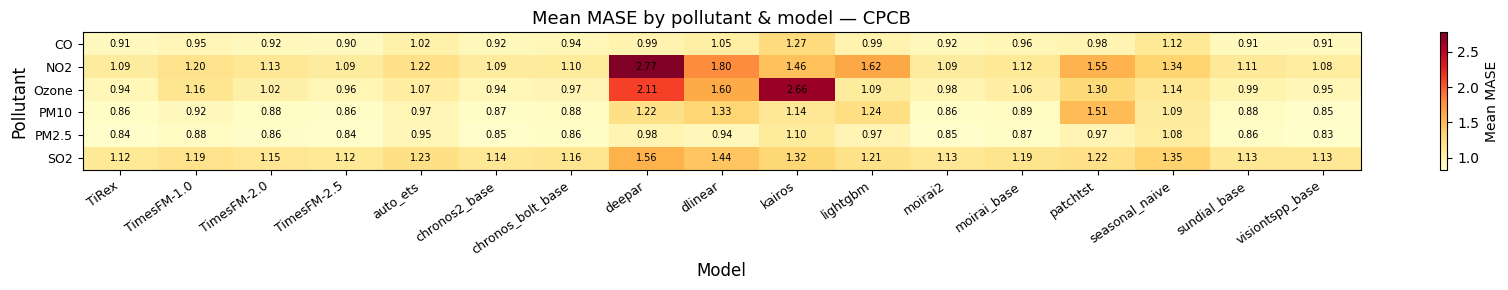

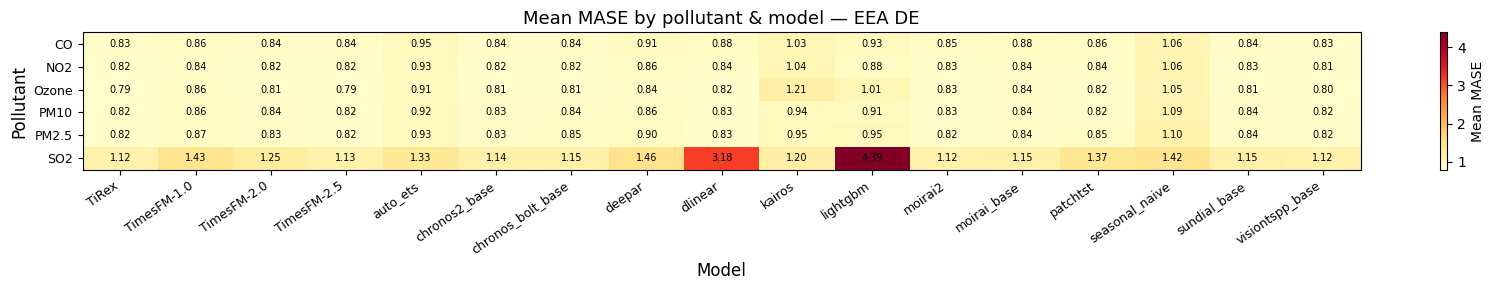

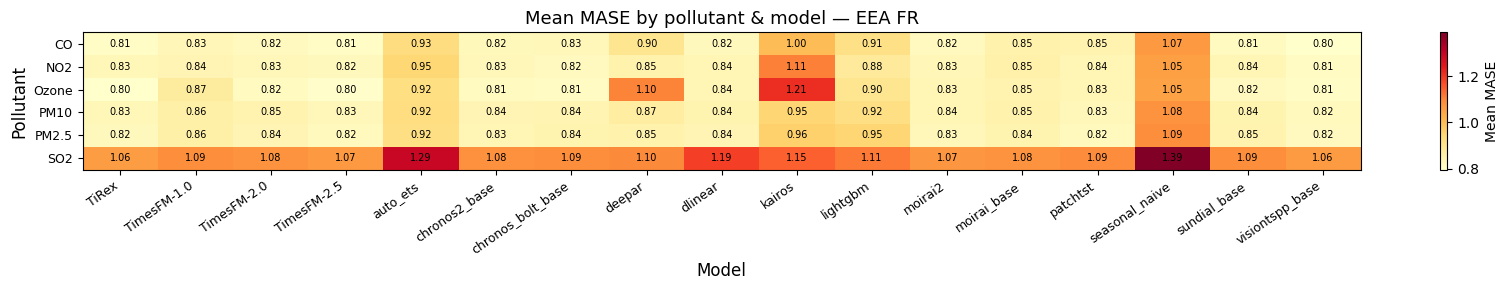

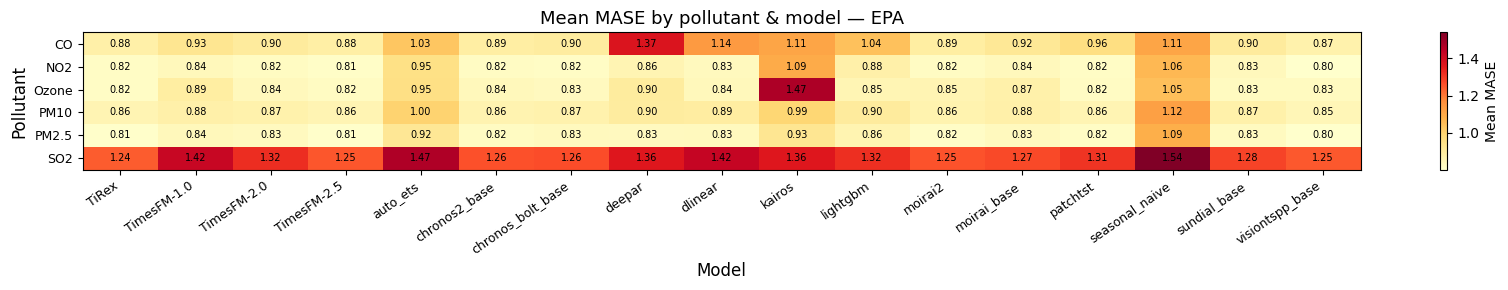

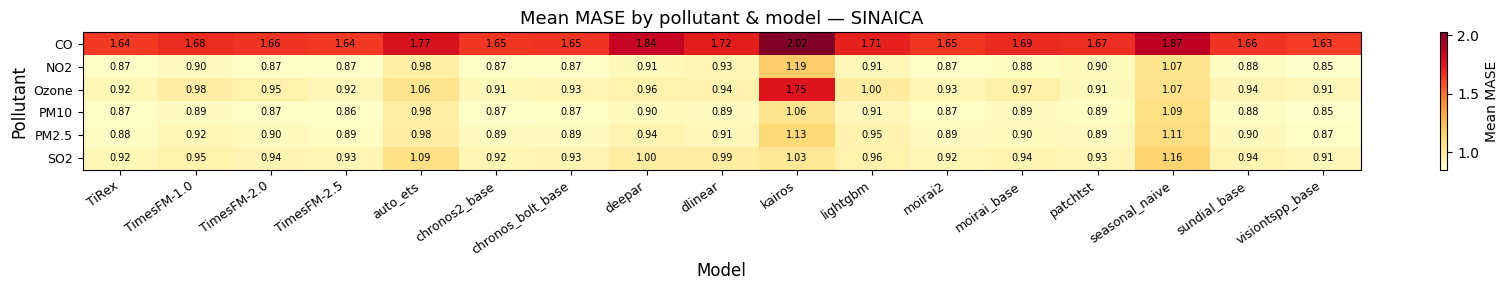

In [8]:
# ── Raw Pollutant × Model MASE heatmaps per dataset ──────────────────────────
# ── Load aggregated per-pollutant results ─────────────────────────────────────
pollutant_results = get_per_pollutant_results(RESULTS_ROOT)
dataset_ids = sorted(pollutant_results["dataset_id"].unique())

def _gmean(x):
    valid = x.dropna()
    return stats.gmean(valid) if len(valid) > 0 else np.nan

for dataset_id in dataset_ids:
    ds_label = display_dataset(dataset_id)
    ddf = pollutant_results[pollutant_results["dataset_id"] == dataset_id]
    sorted_names = sorted(ddf["model"].unique())

    # Mean MASE across horizons per (model, pollutant) — no normalization
    avg = ddf.groupby(["model", "pollutant"])["MASE"].mean().reset_index()
    pivot = avg.pivot(index="pollutant", columns="model", values="MASE")

    pollutants = list(pivot.index)
    models_in_pivot = [m for m in sorted_names if m in pivot.columns]
    matrix = pivot.loc[pollutants, models_in_pivot].values

    fig, ax = plt.subplots(figsize=(max(6, len(models_in_pivot) * 1.0), max(3, len(pollutants) * 0.5)))
    im = ax.imshow(matrix, aspect="auto", cmap="YlOrRd")
    plt.colorbar(im, ax=ax, label="Mean MASE")
    ax.set_xticks(range(len(models_in_pivot)))
    ax.set_xticklabels(models_in_pivot, rotation=35, ha="right", fontsize=9)
    ax.set_yticks(range(len(pollutants)))
    ax.set_yticklabels(pollutants, fontsize=9)
    ax.set_xlabel("Model", fontsize=12)
    ax.set_ylabel("Pollutant", fontsize=12)
    ax.set_title(f"Mean MASE by pollutant & model — {ds_label}", fontsize=13)

    for i in range(len(pollutants)):
        for j in range(len(models_in_pivot)):
            v = matrix[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7)
    plt.tight_layout()
    plt.show()

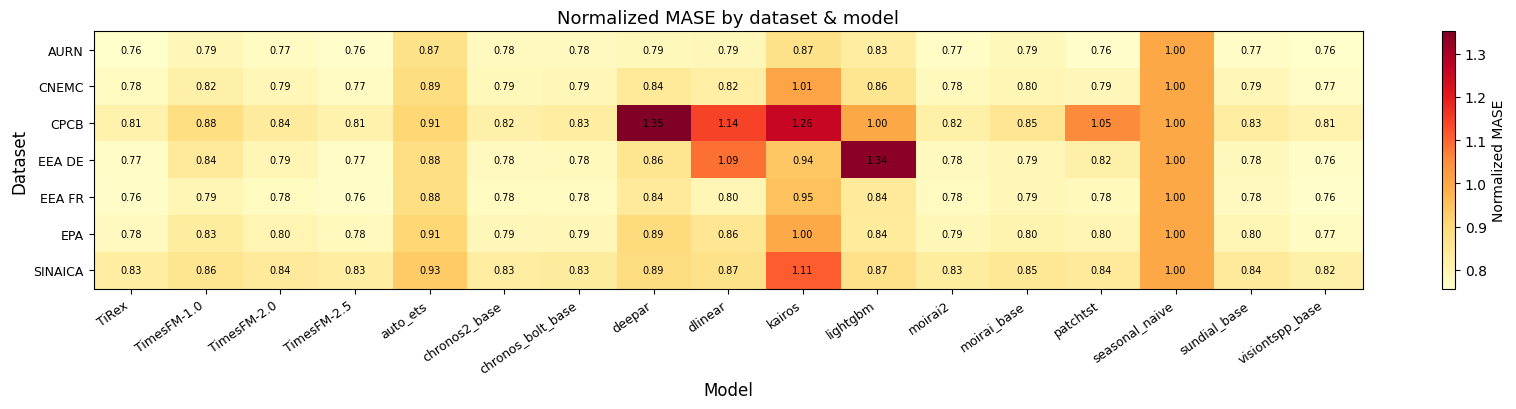

In [9]:
# ── Normalized Dataset × Model MASE heatmap ──────────────────────────────────

per_pol = pollutant_results.groupby(
    ["model", "dataset_id", "horizon", "pollutant"], as_index=False
)["MASE"].mean()
balanced = per_pol.groupby(
    ["model", "dataset_id", "horizon"], as_index=False
)["MASE"].mean()

balanced_norm = normalize_by_seasonal_naive(
    balanced,
    baseline_model=SEASONAL_NAIVE_MODEL,
    metrics=["MASE"],
    groupby_cols=["dataset_id", "horizon"],
)

avg = balanced_norm.groupby(["model", "dataset_id"], as_index=False)["MASE"].mean()
avg["dataset"] = avg["dataset_id"].apply(display_dataset)

pivot = avg.pivot(index="dataset", columns="model", values="MASE")
datasets = list(pivot.index)
models = sorted(pivot.columns)
matrix = pivot.loc[datasets, models].values

fig, ax = plt.subplots(figsize=(max(6, len(models) * 1.0), max(3, len(datasets) * 0.6)))
im = ax.imshow(matrix, aspect="auto", cmap="YlOrRd")
plt.colorbar(im, ax=ax, label="Normalized MASE")

ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=35, ha="right", fontsize=9)
ax.set_yticks(range(len(datasets)))
ax.set_yticklabels(datasets, fontsize=9)
ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("Dataset", fontsize=12)
ax.set_title("Normalized MASE by dataset & model", fontsize=13)

for i in range(len(datasets)):
    for j in range(len(models)):
        v = matrix[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7)

plt.tight_layout()
plt.show()

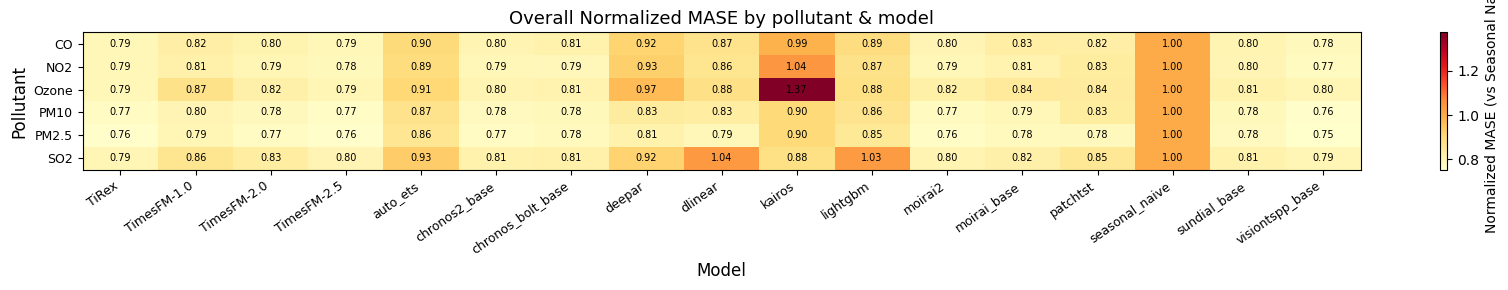

In [10]:
# ── Overall Normalized Pollutant × Model heatmap (across all datasets) ────────
# Same as _save_per_pollutant_table: normalize per (dataset_id, horizon, pollutant),
# then gmean across (dataset_id, horizon) per (model, pollutant)

per_pol_all = pollutant_results.groupby(
    ["model", "dataset_id", "horizon", "pollutant"], as_index=False
)["MASE"].mean()

per_pol_norm = normalize_by_seasonal_naive(
    per_pol_all,
    baseline_model=SEASONAL_NAIVE_MODEL,
    metrics=["MASE"],
    groupby_cols=["dataset_id", "horizon", "pollutant"],
)

avg = per_pol_norm.groupby(["model", "pollutant"])["MASE"].agg(_gmean).reset_index()
pivot = avg.pivot(index="pollutant", columns="model", values="MASE")

pollutants = list(pivot.index)
models = sorted(pivot.columns)
matrix = pivot.loc[pollutants, models].values

fig, ax = plt.subplots(figsize=(max(6, len(models) * 1.0), max(3, len(pollutants) * 0.5)))
im = ax.imshow(matrix, aspect="auto", cmap="YlOrRd")
plt.colorbar(im, ax=ax, label="Normalized MASE (vs Seasonal Naive)")

ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=35, ha="right", fontsize=9)
ax.set_yticks(range(len(pollutants)))
ax.set_yticklabels(pollutants, fontsize=9)
ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("Pollutant", fontsize=12)
ax.set_title("Overall Normalized MASE by pollutant & model", fontsize=13)

for i in range(len(pollutants)):
    for j in range(len(models)):
        v = matrix[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7)

plt.tight_layout()
plt.show()